In [1]:
import os
import matplotlib.pyplot as plt
plt.style.use("paper.mplstyle")

In [2]:
#Imorting File sizes for Normalizing Flow and those avaliable for the Histogram-based method
filenames_flow = [
    "../Files/PTA/PHASE_TIME_AMP_L1V1_FLOW.h5",
    "../Files/PTA/PHASE_TIME_AMP_L1H1V1_FLOW.h5",
    "../Files/4det/PHASE_TIME_AMP_L1H1V1K1_FLOW.h5",
    "../Files/4det/PHASE_TIME_AMP_L1H1V1K1A1_FLOW.h5",
]
size_mb_flow = []
for fname in filenames_flow:
    size_bytes = os.path.getsize(fname)
    size_mb = size_bytes / (1024**2)
    size_mb_flow.append(size_mb)
    print(f"{fname}: {size_bytes} bytes ({size_mb:.2f} MB)")

filenames_original = [
    "../Files/PTA/L1V1-PHASE_TIME_AMP_O4b.hdf",
    "../Files/PTA/L1H1V1-PHASE_TIME_AMP_O4b.hdf",
]

size_mb_original = []
for fname in filenames_original:
    size_bytes = os.path.getsize(fname)
    size_mb = size_bytes / (1024**2)
    size_mb_original.append(size_mb)
    print(f"{fname}: {size_bytes} bytes ({size_mb:.2f} MB)")

../Files/PTA/PHASE_TIME_AMP_L1V1_FLOW.h5: 59128 bytes (0.06 MB)
../Files/PTA/PHASE_TIME_AMP_L1H1V1_FLOW.h5: 1235440 bytes (1.18 MB)
../Files/4det/PHASE_TIME_AMP_L1H1V1K1_FLOW.h5: 3308040 bytes (3.15 MB)
../Files/4det/PHASE_TIME_AMP_L1H1V1K1A1_FLOW.h5: 4654344 bytes (4.44 MB)
../Files/PTA/L1V1-PHASE_TIME_AMP_O4b.hdf: 8978397 bytes (8.56 MB)
../Files/PTA/L1H1V1-PHASE_TIME_AMP_O4b.hdf: 2211482550 bytes (2109.03 MB)


In [3]:
#Estimating file sizes for 4 and 5 detectors based on the scaling from 2 to 3 detectors

est_4det_size = size_mb_original[1] * size_mb_original[1]/size_mb_original[0]
est_5det_size = est_4det_size * size_mb_original[1]/size_mb_original[0]
size_mb_original.append(est_4det_size)
size_mb_original.append(est_5det_size)

Number_of_Detectors = [2, 3, 4, 5]

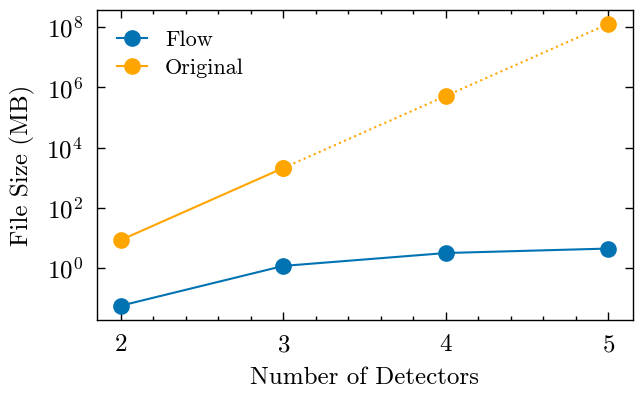

In [4]:
# Plotting File sizes as a function of number of detectors

plt.plot(Number_of_Detectors, size_mb_flow, marker='o', label='Flow')
plt.plot(Number_of_Detectors[:2], size_mb_original[:2],
         marker='o', color="orange", linestyle='solid', label='Original')
plt.plot(Number_of_Detectors[1:], size_mb_original[1:],
         marker='o', color="orange", linestyle='dotted')
plt.xticks(Number_of_Detectors)
plt.xlabel('Number of Detectors')
plt.ylabel('File Size (MB)')

plt.yscale('log')
plt.legend()
plt.savefig("../Plots/File_size_vs_Number_of_Detectors.png")
plt.show()